In [25]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
from pathlib import Path

from brainvision.constants import *
from brainvision.models import (Baseline1DDNN, FabeloDNN, Fabelo2DCNN,
                                 HuEtAl1DCNN, LeeEtAl2DCNN,
                                 HamidaEtAl3DCNN, HybridSN, SpectralFormer)
from brainvision.data import HSIPixelDataset, HSIPatchDataset
from brainvision.data.io import load_all_campaigns
from brainvision.validation import get_splits
from brainvision.utils import build_run_name
from brainvision.metrics import (compute_metrics, aggregate_fold_metrics,
                                  print_metrics, print_aggregate)
from brainvision.history import plot_history_curves, load_history
from brainvision.device import get_device, print_device_info, empty_device_cache

In [26]:
device = get_device()
print_device_info(device)

  Device     : MPS
  Name       : Apple Silicon (MPS)
  Memory     : 19,070 MB total  | N/A free  | N/A used


In [27]:
MODEL    = "1D-CNN"      # "1D-NN" | "1D-NN-Fabelo" | "1D-CNN" | "2D-CNN" | "3D-CNN" | "SF"
LOSS_FN  = "CE"                 # "CE" | "FL" | "DL" | "UFL"
STRATEGY = "vp_fabelo"          # "vp1" | "vp2" | "vp3" | "lopo" | "vp_fabelo"
N_FOLDS  = 5                    # used for vp3 and lopo only; vp_fabelo always uses 5 folds

REDUCE_PIXELS = True            # apply K-Means reduction to training set

In [28]:
PATCH_MODELS = {'2D-CNN', '2D-CNN-Fabelo', '3D-CNN', 'HybridSN'}

MODEL_REGISTRY = {
    '1D-NN'         : lambda: Baseline1DDNN(N_DECIMATED_BANDS, N_CLASSES,
                                             dropout=True,
                                             dropout_rate=DROPOUT_RATE),
    '1D-NN-Fabelo'  : lambda: FabeloDNN(N_DECIMATED_BANDS, N_CLASSES),
    '1D-CNN'        : lambda: HuEtAl1DCNN(N_DECIMATED_BANDS, N_CLASSES),
    '2D-CNN'        : lambda: LeeEtAl2DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                             PATCH_SIZE),
    '2D-CNN-Fabelo' : lambda: Fabelo2DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                         PATCH_SIZE),
    '3D-CNN'        : lambda: HamidaEtAl3DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                               PATCH_SIZE),
    'HybridSN'      : lambda: HybridSN(N_DECIMATED_BANDS, PATCH_SIZE,
                                        N_CLASSES),
    'SpectralFormer': lambda: SpectralFormer(N_DECIMATED_BANDS, N_CLASSES,
                                              near_band    = SF_NEAR_BAND,
                                              dim          = SF_DIM,
                                              depth        = SF_DEPTH,
                                              heads        = SF_HEADS,
                                              dim_head     = SF_DIM_HEAD,
                                              mlp_dim      = SF_MLP_DIM,
                                              dropout      = SF_DROPOUT,
                                              emb_dropout  = SF_EMB_DROPOUT,
                                              mode         = SF_MODE),
}

In [29]:
campaigns = load_all_campaigns(PROCESSED_DIRS)

Campaigns loaded from memory cache (61 patients across 3 campaigns)


In [30]:
all_splits = get_splits(campaigns, STRATEGY)


════════════════════════════════════════════════════════════
  Training Curves — 1D-CNN × CE × vp_fabelo
════════════════════════════════════════════════════════════


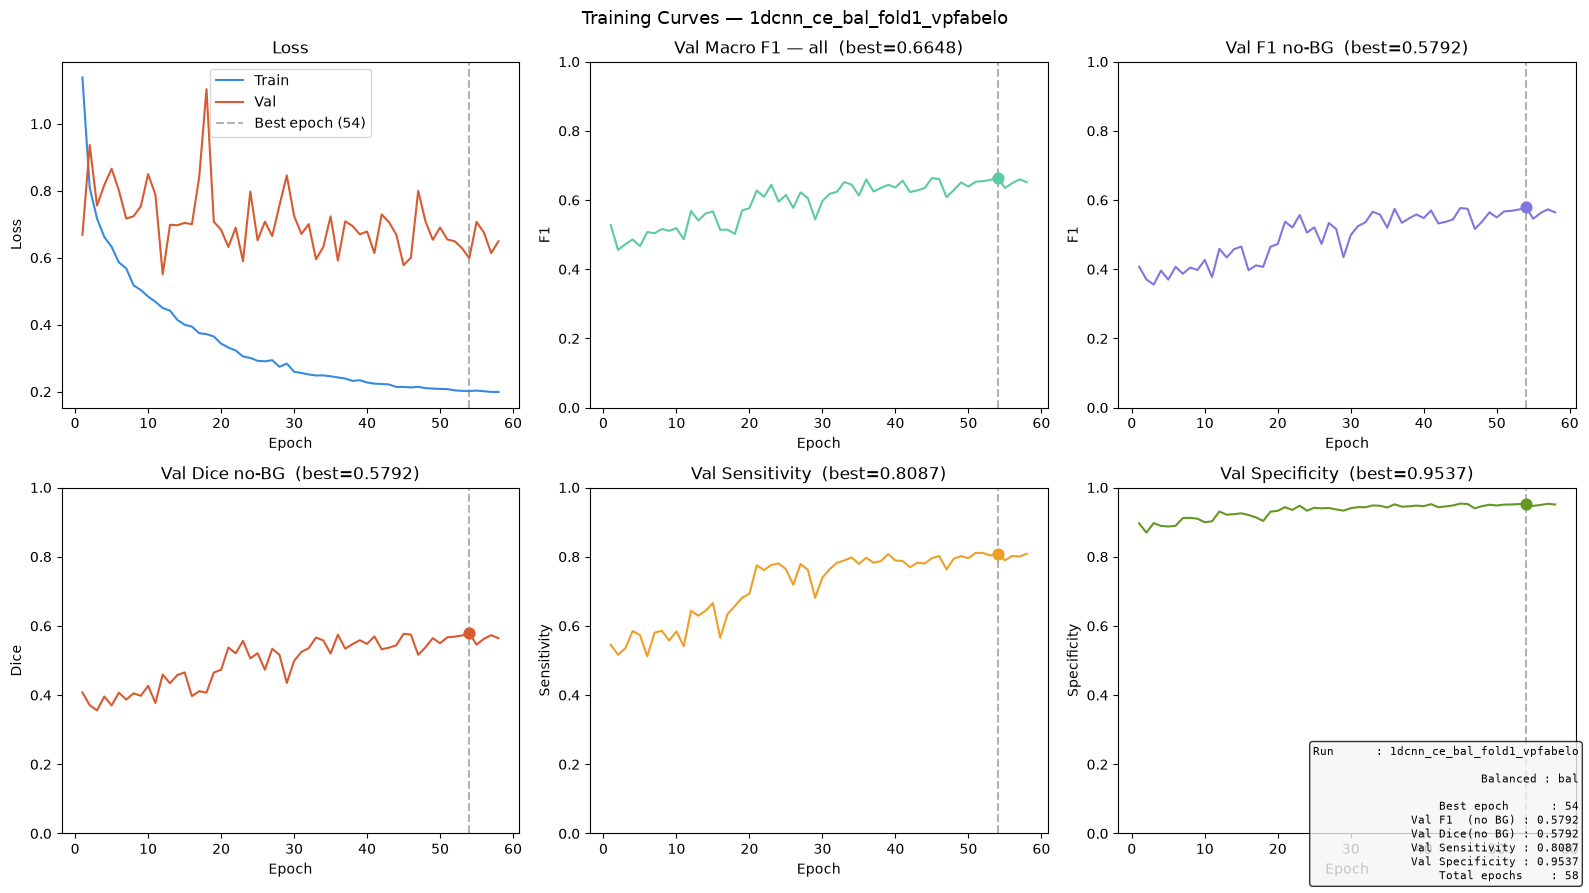

  Saved → ../results/1dcnn_ce_bal_fold1_vpfabelo_curves.png


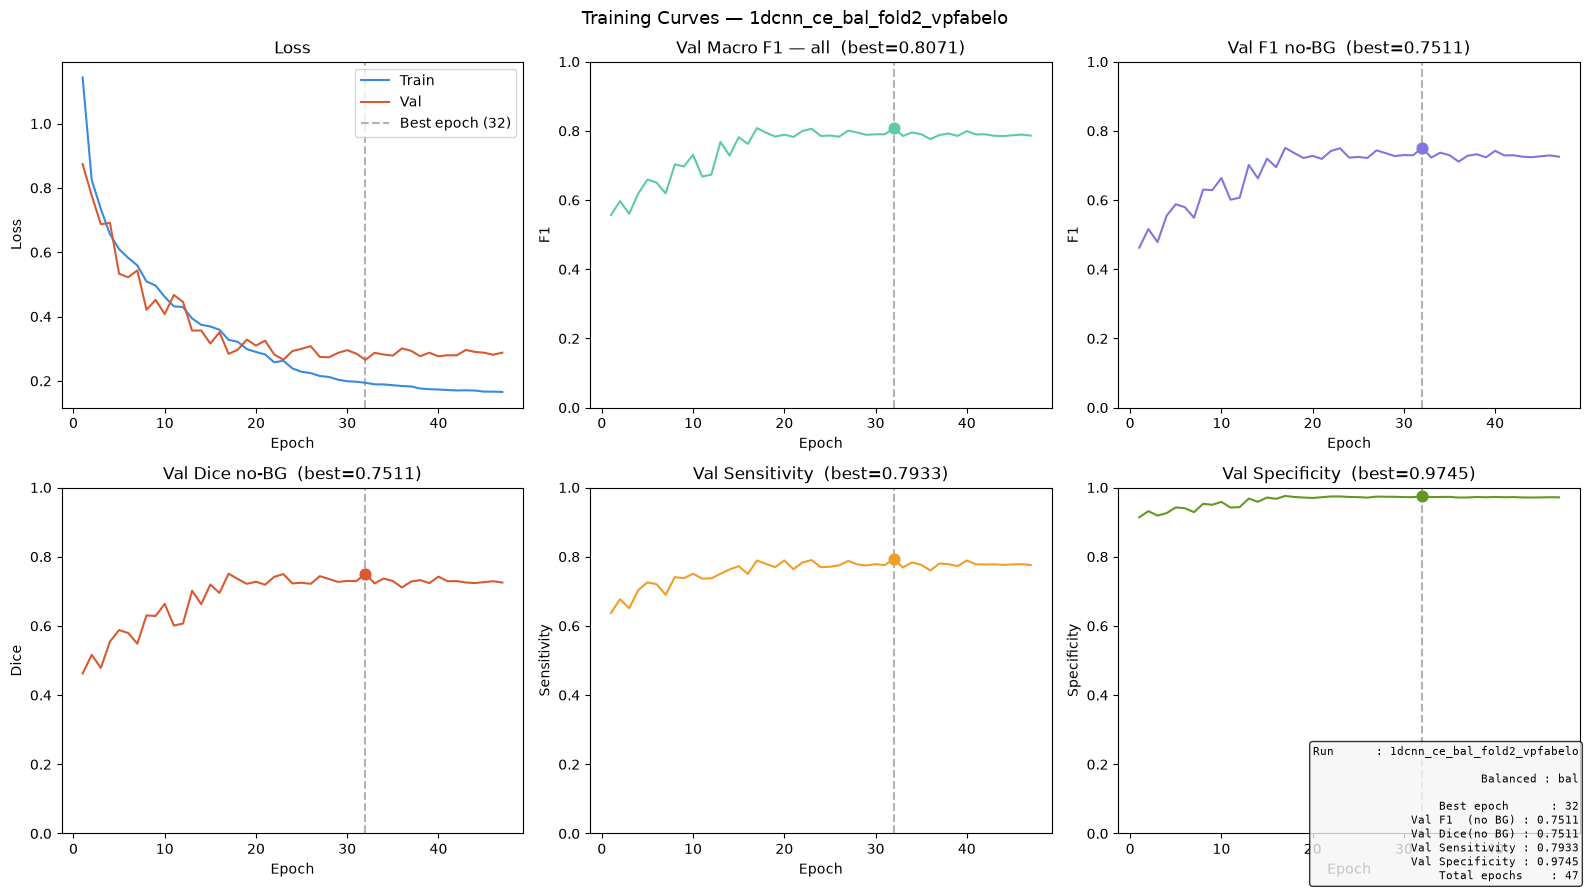

  Saved → ../results/1dcnn_ce_bal_fold2_vpfabelo_curves.png


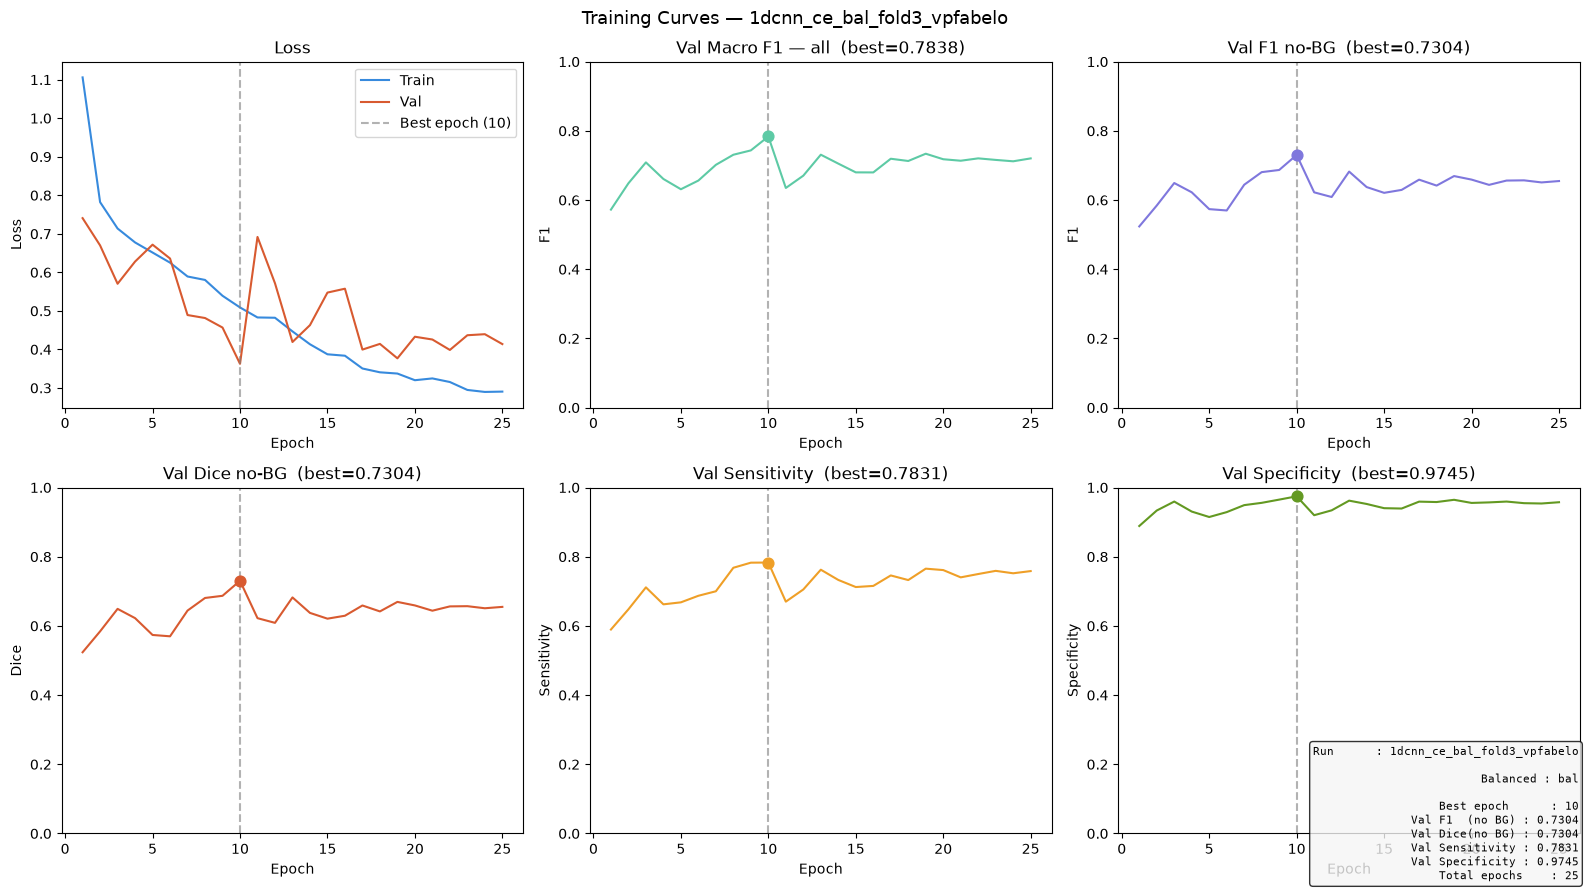

  Saved → ../results/1dcnn_ce_bal_fold3_vpfabelo_curves.png


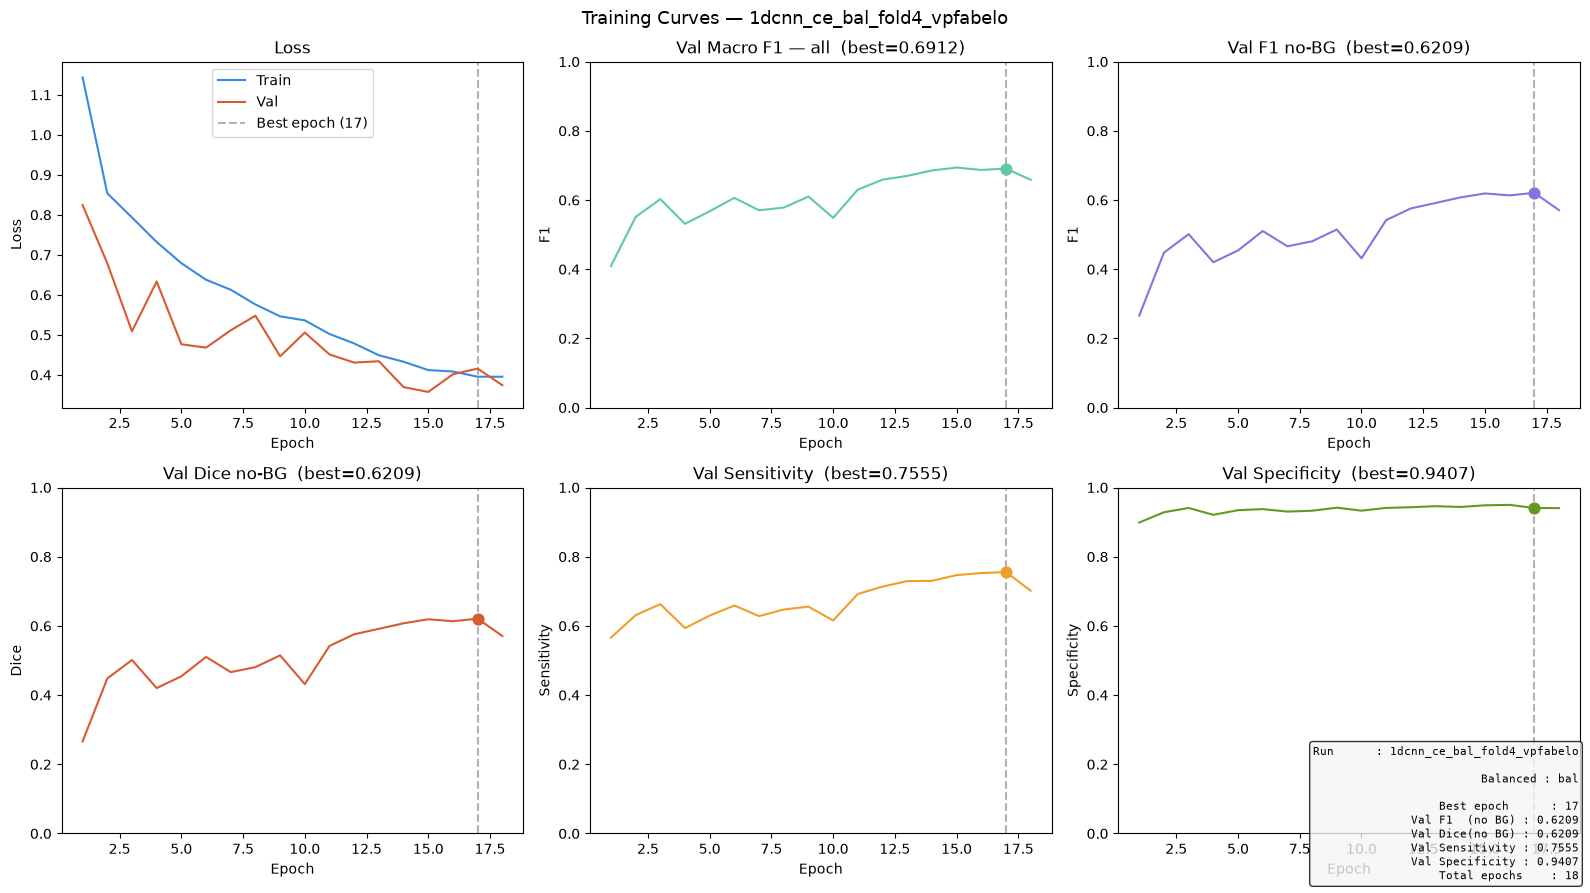

  Saved → ../results/1dcnn_ce_bal_fold4_vpfabelo_curves.png


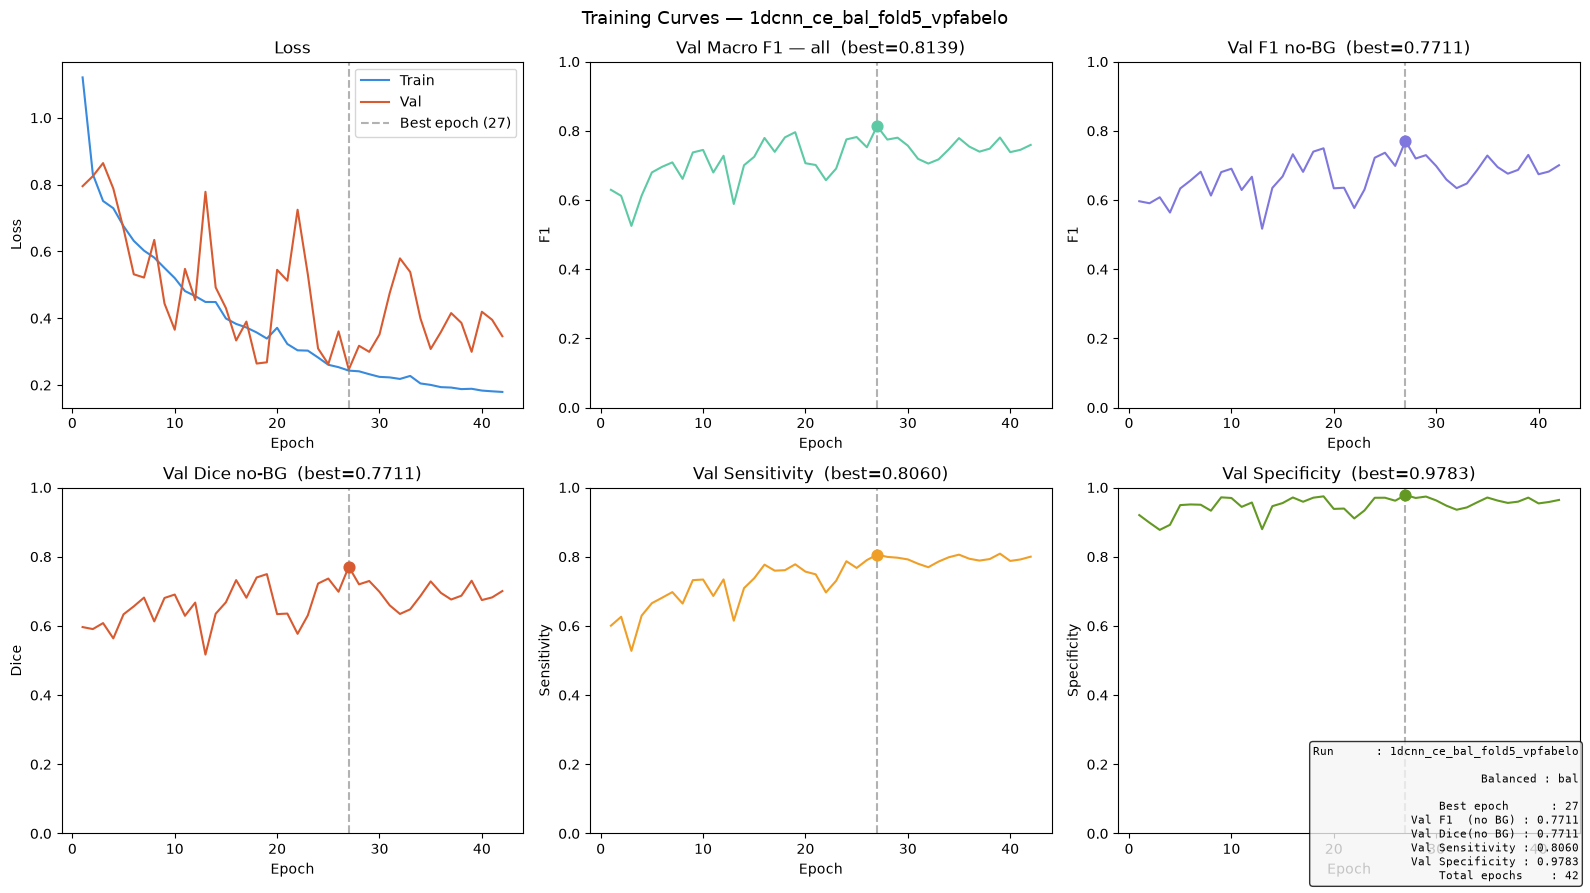

  Saved → ../results/1dcnn_ce_bal_fold5_vpfabelo_curves.png


In [31]:
print(f"\n{'═'*60}")
print(f"  Training Curves — {MODEL} × {LOSS_FN} × {STRATEGY}")
print(f"{'═'*60}")

for split in all_splits:
    cfg = {
        "model": MODEL,
        "loss": LOSS_FN,
        "reduce_pixels": REDUCE_PIXELS,
        "strategy": STRATEGY,
        "fold": split["fold"]
    }
    run_name = build_run_name(
        model         = cfg['model'],
        loss_fn       = cfg['loss'],
        strategy      = cfg['strategy'],
        fold          = cfg['fold'],
        reduce_pixels = cfg['reduce_pixels'],
    )
    history  = load_history(cfg, RESULTS_DIR)
    if history:
        plot_history_curves(history, run_name, RESULTS_DIR)

In [32]:
@torch.no_grad()
def predict(model, loader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_preds, all_targets = [], []
    for X, y in loader:
        X      = X.to(device)
        logits = model(X)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_targets.extend(y.numpy())
    return np.array(all_preds), np.array(all_targets)


def plot_confusion_matrix(metrics: dict):
    cm   = metrics['confusion_matrix']
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp    = ConfusionMatrixDisplay(
        confusion_matrix = cm_n,
        display_labels   = [CLASS_NAMES_SHORT[i+1] for i in range(N_CLASSES)]
    )
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
    ax.set_title(f"Confusion Matrix — {metrics['run_name']}")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{metrics['run_name']}_cm.png",
                dpi=150, bbox_inches='tight')
    plt.show()


def build_test_loader(split: dict) -> DataLoader:
    """Build test DataLoader — always unbalanced, never augmented."""
    test_patients = split['test']
    if MODEL in PATCH_MODELS:
        test_dataset = HSIPatchDataset(
            test_patients,
            patch_size = PATCH_SIZE,
            balance    = False,
            augment    = False,
        )
    else:
        test_dataset = HSIPixelDataset(test_patients)
    return DataLoader(test_dataset, batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=0, pin_memory=True)

In [33]:
def evaluate_fold(split: dict) -> dict | None:
    cfg = {
        "model": MODEL,
        "loss": LOSS_FN,
        "reduce_pixels": REDUCE_PIXELS,
        "strategy": STRATEGY,
        "fold": split["fold"]
    }
    run_name = build_run_name(
        model         = cfg['model'],
        loss_fn       = cfg['loss'],
        strategy      = cfg['strategy'],
        fold          = cfg['fold'],
        reduce_pixels = cfg['reduce_pixels'],
    )
    checkpoint_path = Path(CHECKPOINTS_DIR) / f"{run_name}.pt"

    if not checkpoint_path.exists():
        print(f"  ⚠️  Checkpoint not found: {checkpoint_path}")
        return None

    print(f"\n{'─'*60}")
    print(f"  Evaluating : {run_name}")
    if 'val_patient' in split:
        print(f"  Val patient: {split['val_patient']}")
    print(f"  Test images: {len(split['test'])}")
    print(f"{'─'*60}")

    test_loader = build_test_loader(split)

    model = MODEL_REGISTRY[MODEL]().to(device)
    model.load_state_dict(
        torch.load(checkpoint_path, map_location=device, weights_only=True)
    )

    preds, targets = predict(model, test_loader)
    metrics        = compute_metrics(targets, preds, run_name)

    print_metrics(metrics)
    plot_confusion_matrix(metrics)

    print(classification_report(
        targets, preds,
        target_names = [CLASS_NAMES[i+1] for i in range(N_CLASSES)],
        digits=4, zero_division=0
    ))

    np.save(f"{RESULTS_DIR}/{run_name}_test_metrics.npy", metrics)
    print(f"  Saved → {RESULTS_DIR}/{run_name}_test_metrics.npy")

    del model
    empty_device_cache()

    return metrics


────────────────────────────────────────────────────────────
  Evaluating : 1dcnn_ce_bal_fold1_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dcnn_ce_bal_fold1_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.8044
  Macro F1  (all classes)    : 0.7357
  Macro F1  (no BG)          : 0.7109  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.7357
  Macro Dice (no BG)         : 0.7109

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8632       0.9389   0.8896   0.8896
  Tumour Tissue (TT)              0.8009       0.9202   0.5040   0.5040  ← clinical priority
  Blood Vessel (BV)               0.8011       0.9246   0.7390   0.7390
  Background (BG)                 0.7290       0.9647   0.8103   0.8103
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7986       0.9371   0.735

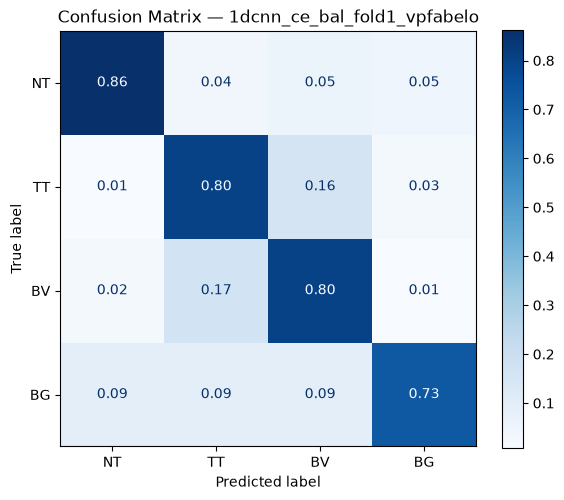

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9177    0.8632    0.8896    108722
Tumour Tissue (TT)     0.3677    0.8009    0.5040     13500
 Blood Vessel (BV)     0.6858    0.8011    0.7390     42005
   Background (BG)     0.9119    0.7290    0.8103     82318

          accuracy                         0.8044    246545
         macro avg     0.7208    0.7986    0.7357    246545
      weighted avg     0.8461    0.8044    0.8164    246545

  Saved → ../results/1dcnn_ce_bal_fold1_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : 1dcnn_ce_bal_fold2_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dcnn_ce_bal_fold2_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.8196
  Macro F1  (all classes)    : 0.7506
  Macro F1  (no BG)          : 0.7341  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.7506
  Macro Dice (no BG)         : 0.7341

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8621       0.9435   0.8916   0.8916
  Tumour Tissue (TT)              0.6465       0.9469   0.5044   0.5044  ← clinical priority
  Blood Vessel (BV)               0.9218       0.9251   0.8063   0.8063
  Background (BG)                 0.7397       0.9453   0.8002   0.8002
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7925       0.9402   0.750

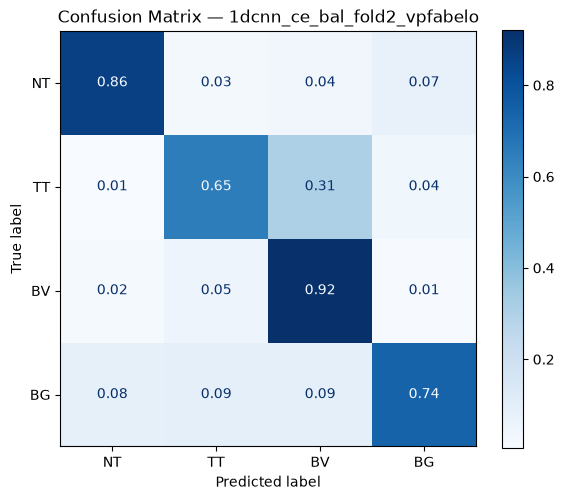

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9233    0.8621    0.8916    108722
Tumour Tissue (TT)     0.4135    0.6465    0.5044     13500
 Blood Vessel (BV)     0.7165    0.9218    0.8063     42005
   Background (BG)     0.8715    0.7397    0.8002     82318

          accuracy                         0.8196    246545
         macro avg     0.7312    0.7925    0.7506    246545
      weighted avg     0.8428    0.8196    0.8254    246545

  Saved → ../results/1dcnn_ce_bal_fold2_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : 1dcnn_ce_bal_fold3_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dcnn_ce_bal_fold3_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.8137
  Macro F1  (all classes)    : 0.6801
  Macro F1  (no BG)          : 0.6368  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.6801
  Macro Dice (no BG)         : 0.6368

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8714       0.8801   0.8613   0.8613
  Tumour Tissue (TT)              0.1458       0.9965   0.2416   0.2416  ← clinical priority
  Blood Vessel (BV)               0.9621       0.9135   0.8074   0.8074
  Background (BG)                 0.7712       0.9336   0.8102   0.8102
  ────────────────────────────────────────────────────────────────────
  Mean                            0.6876       0.9309   0.680

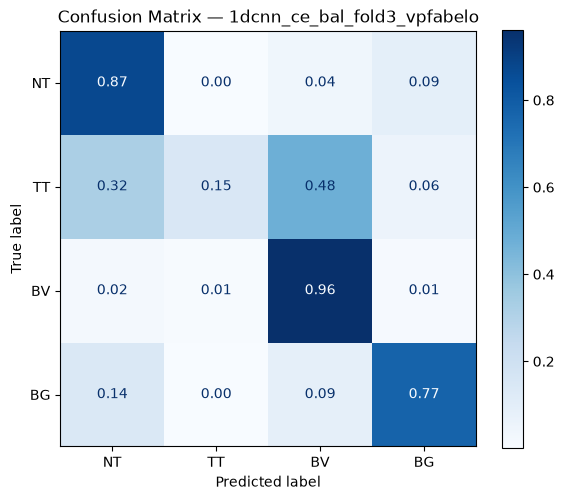

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.8514    0.8714    0.8613    108722
Tumour Tissue (TT)     0.7051    0.1458    0.2416     13500
 Blood Vessel (BV)     0.6956    0.9621    0.8074     42005
   Background (BG)     0.8535    0.7712    0.8102     82318

          accuracy                         0.8137    246545
         macro avg     0.7764    0.6876    0.6801    246545
      weighted avg     0.8176    0.8137    0.8011    246545

  Saved → ../results/1dcnn_ce_bal_fold3_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : 1dcnn_ce_bal_fold4_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dcnn_ce_bal_fold4_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.7845
  Macro F1  (all classes)    : 0.7122
  Macro F1  (no BG)          : 0.6932  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.7122
  Macro Dice (no BG)         : 0.6932

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8620       0.9351   0.8867   0.8867
  Tumour Tissue (TT)              0.7839       0.9071   0.4629   0.4629  ← clinical priority
  Blood Vessel (BV)               0.7282       0.9452   0.7300   0.7300
  Background (BG)                 0.7109       0.9310   0.7692   0.7692
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7713       0.9296   0.712

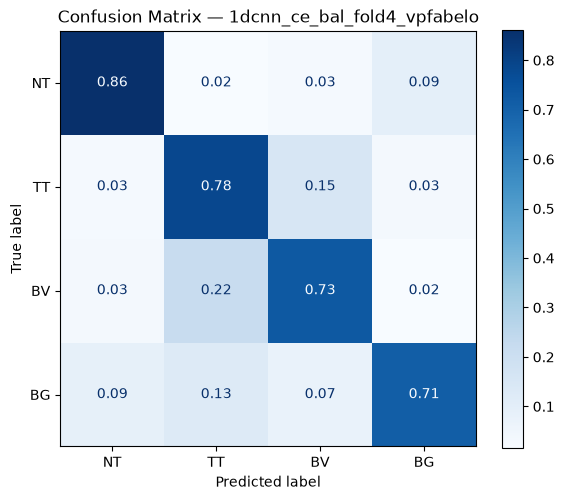

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9128    0.8620    0.8867    108722
Tumour Tissue (TT)     0.3284    0.7839    0.4629     13500
 Blood Vessel (BV)     0.7317    0.7282    0.7300     42005
   Background (BG)     0.8379    0.7109    0.7692     82318

          accuracy                         0.7845    246545
         macro avg     0.7027    0.7713    0.7122    246545
      weighted avg     0.8249    0.7845    0.7975    246545

  Saved → ../results/1dcnn_ce_bal_fold4_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : 1dcnn_ce_bal_fold5_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dcnn_ce_bal_fold5_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.8238
  Macro F1  (all classes)    : 0.7581
  Macro F1  (no BG)          : 0.7347  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.7581
  Macro Dice (no BG)         : 0.7347

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8715       0.9300   0.8892   0.8892
  Tumour Tissue (TT)              0.6510       0.9593   0.5534   0.5534  ← clinical priority
  Blood Vessel (BV)               0.8726       0.9139   0.7615   0.7615
  Background (BG)                 0.7643       0.9592   0.8282   0.8282
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7899       0.9406   0.758

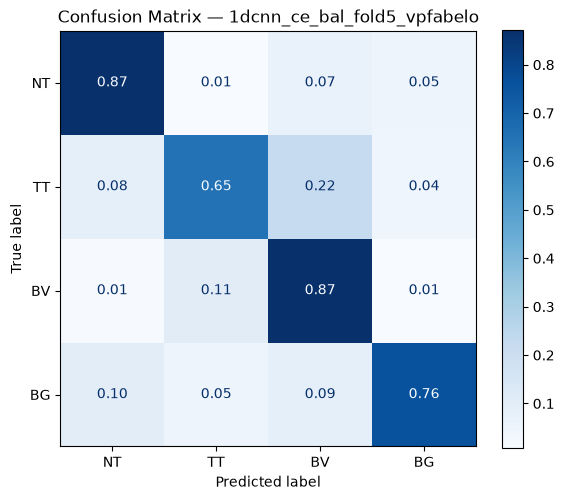

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9076    0.8715    0.8892    108722
Tumour Tissue (TT)     0.4812    0.6510    0.5534     13500
 Blood Vessel (BV)     0.6755    0.8726    0.7615     42005
   Background (BG)     0.9038    0.7643    0.8282     82318

          accuracy                         0.8238    246545
         macro avg     0.7420    0.7899    0.7581    246545
      weighted avg     0.8434    0.8238    0.8287    246545

  Saved → ../results/1dcnn_ce_bal_fold5_vpfabelo_test_metrics.npy


In [34]:
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

all_metrics = []
for split in all_splits:
    metrics = evaluate_fold(split)
    if metrics:
        all_metrics.append(metrics)

In [35]:
aggregate = aggregate_fold_metrics(all_metrics)

In [36]:
print_aggregate(aggregate, model=MODEL, loss_fn=LOSS_FN, strategy=STRATEGY)


═════════════════════════════════════════════════════════════════
  AGGREGATE — 1D-CNN × CE × vp_fabelo
  5 folds
═════════════════════════════════════════════════════════════════
  Macro F1  (all)    : 73.6 ± 2.8%
  Macro F1  (no BG)  : 71.1 ± 3.6%  ← vs Fabelo 70.2 ± 7.9%
  Macro Dice (all)   : 73.6 ± 2.8%
  Macro Dice (no BG) : 71.1 ± 3.6%
  OA                 : 81.4 ± 1.4%

  Class      Sens     ±     Spec     ±      Dice     ±
  ───────────────────────────────────────────────────────
  NT        86.3%   ± 0.4%     93.5%   ± 2.3%     88.9%   ± 1.1%
  TT        65.1%   ±23.9%     94.7%   ± 3.1%     50.4%   ±11.0%  ← clinical priority
  BV        87.3%   ± 8.4%     92.5%   ± 1.1%     76.2%   ± 3.3%
  BG        74.0%   ± 2.2%     94.5%   ± 1.3%     81.0%   ± 1.9%

  Per-fold F1 (no BG)  : ['71.1%', '73.4%', '63.7%', '69.3%', '73.5%']
  Per-fold Dice (no BG): ['71.1%', '73.4%', '63.7%', '69.3%', '73.5%']
